# 01 - Exploratory Data Analysis: Financial PhraseBank

Before writing any preprocessing or modelling code, it's worth spending time
just *looking* at the data. This notebook explores the Financial PhraseBank
dataset (5,842 labelled financial sentences) and surfaces a few findings that
directly shaped decisions made in `src/preprocessor.py` and
`src/classical_models.py`.

Specifically, I am trying to answer:

1. How imbalanced are the sentiment classes, and does that matter?
2. Are headlines short enough that BERT's 512-token limit is a non-issue?
3. Do the "financial signal words" I plan to protect from stop-word removal
   (bullish, bearish, downgrade, rally, ...) actually correlate with
   sentiment in this data - or is that just an assumption?


In [8]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_dataset

sns.set_theme(style="whitegrid", palette="muted")

df = load_dataset()
df.head()

,Sentence,Sentiment,text_length
0,The GeoSolutions technology will leverage Bene...,positive,32
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,11
2,"For the last quarter of 2010 , Componenta 's n...",positive,39
3,According to the Finnish-Russian Chamber of Co...,neutral,20
4,The Swedish buyout firm has sold its remaining...,neutral,23


## 1. Class distribution

A 3-class sentiment problem with classes this imbalanced has a trap: a model
that *only ever predicts the majority class* scores deceptively well on
accuracy alone.

neutral   : 3,130 ( 53.6%)
positive  : 1,852 ( 31.7%)
negative  :   860 ( 14.7%)


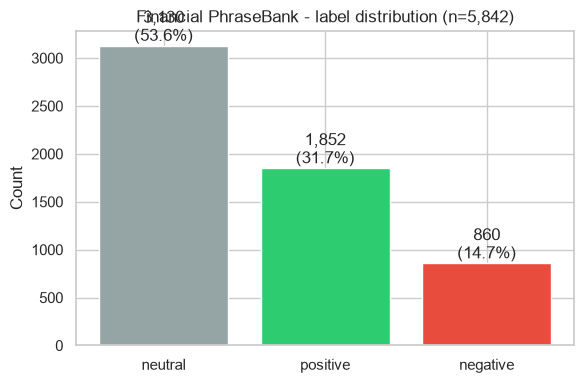

In [9]:
counts = df["Sentiment"].value_counts()
pct = (counts / len(df) * 100).round(1)

for label in counts.index:
    print(f"{label:10s}: {counts[label]:5,} ({pct[label]:5.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
colors = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#95a5a6"}
bars = ax.bar(counts.index, counts.values,
               color=[colors[c] for c in counts.index])
ax.bar_label(bars, labels=[f"{v:,}\n({p}%)" for v, p in zip(counts.values, pct.values)])
ax.set_title("Financial PhraseBank - label distribution (n=5,842)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

**Finding:** `neutral` is 53.6% of the data - a model that predicts
"neutral" for everything scores 53.6% accuracy while learning nothing. This
is exactly why `src/classical_models.py` uses `class_weight='balanced'` for
both Logistic Regression and SVM, and why the project README treats
**negative-class F1** (not overall accuracy) as the headline metric: with
only 14.7% of the data, the negative class is the one a naive model would
ignore - and the one a trading/risk system can least afford to miss.

## 2. Headline length distribution

If headlines were very long, I'd need to think about truncation for BERT
(512-token limit). Let's check.

count    5842.0
mean       21.0
std        10.3
min         2.0
25%        13.0
50%        19.0
75%        27.0
max        81.0
Name: word_count, dtype: float64


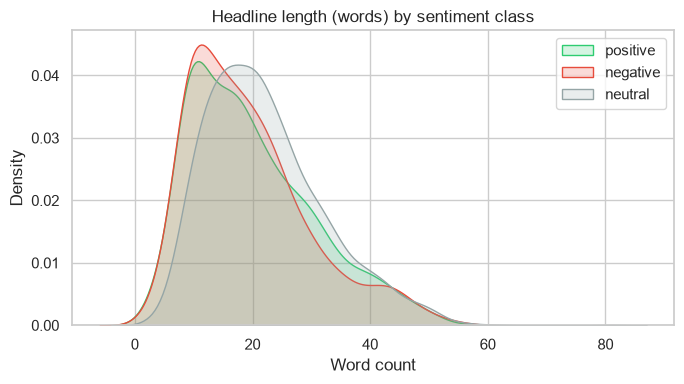

In [10]:
df["word_count"] = df["Sentence"].str.split().str.len()

print(df["word_count"].describe().round(1))

fig, ax = plt.subplots(figsize=(7, 4))
for label, color in colors.items():
    subset = df[df["Sentiment"] == label]["word_count"]
    sns.kdeplot(subset, label=label, color=color, fill=True, alpha=0.2, ax=ax)
ax.set_title("Headline length (words) by sentiment class")
ax.set_xlabel("Word count")
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** headlines max out around 70-80 words, with a median around
20. BERT's 512-token limit (roughly 350-400 English words including
sub-tokens) is far more than needed - the `text[:512]` truncation in
`finbert_model.py` is a defensive guard, not something that actually
triggers on this dataset. The three classes also have very similar length
distributions, so length itself isn't a useful feature for distinguishing
sentiment - the *words* are what matter.

## 3. What do the sentences actually look like?

Numbers only tell part of the story. Reading a few real examples from each
class gives a feel for the vocabulary and tone - and for *why* this is
harder than, say, movie review sentiment.

In [13]:
for label in ["positive", "negative", "neutral"]:
    print(f"    {label.upper()}: ")
    for sentence in df[df["Sentiment"] == label]["Sentence"].sample(3, random_state=1):
        print(f"  - {sentence}")
    print()

    POSITIVE: 
  - $FB gettin in the buy zone soon ;)
  - Net sales went up by 1 % year-on-year to EUR 29 million , affected by the business acquisitions , realized during the previous financial period , the effect of which was EUR 5.1 million on the review period .
  - At the same time I am delighted by the fact that we were able to accomplish the organization with our own team members .

    NEGATIVE: 
  - i-Grid shows $DIA capped for the long term at range of 123.40- 124.77;any rally beyond today's levels or into this range leads to meltdown.
  - Full-year operating result for 2008 was 3.6 million negative .
  - Locked in some $FB puts for nice gain

    NEUTRAL: 
  - Under the agreement , Pfizer has been funding Biotie 's research activities on the PDE10 phosphodiesterase 10 inhibitor program since its start in late 2006 and has the sole authority to develop discovered compounds .
  - HELSINKI ( AFX ) - Outokumpu said it has agreed to sell the Hitura nickel mine in Finland to Canad

**Observation:** positive examples lean on growth/profit/increase
language, negative examples mention losses, layoffs, and declines - but a
striking number of *neutral* examples also contain numbers, percentages, and
company names without any obvious emotional valence (e.g. routine operational
announcements). This is the core difficulty: a model has to distinguish "the
company grew" (positive) from "the company has 200 stores" (neutral) - both
are full of nouns and numbers, but only one carries sentiment.

## 4. Do "financial signal words" actually correlate with sentiment?

`src/preprocessor.py` defines a set of ~40 words (bullish, bearish,
downgrade, rally, profit, loss, ...) that are protected from stop-word
removal on the assumption that they're high-signal for sentiment. Let's check
that assumption empirically rather than taking it on faith: for a sample of
these words, does their presence actually skew the sentiment distribution of
the sentences containing them?

In [14]:
sample_words = ["bullish", "bearish", "downgrade", "rally", "profit",
                "loss", "decline", "growth", "restructuring", "default"]

rows = []
overall = df["Sentiment"].value_counts(normalize=True) * 100

for word in sample_words:
    mask = df["Sentence"].str.contains(rf"\b{word}", case=False, regex=True)
    n = mask.sum()
    if n == 0:
        continue
    dist = df.loc[mask, "Sentiment"].value_counts(normalize=True) * 100
    rows.append({
        "word": word, "n_sentences": n,
        "positive_%": round(dist.get("positive", 0), 1),
        "negative_%": round(dist.get("negative", 0), 1),
        "neutral_%":  round(dist.get("neutral", 0), 1),
    })

signal_df = pd.DataFrame(rows).set_index("word")
print("Overall dataset distribution: pos={:.1f}% neg={:.1f}% neu={:.1f}%".format(
    overall["positive"], overall["negative"], overall["neutral"]))
signal_df

Overall dataset distribution: pos=31.7% neg=14.7% neu=53.6%


,n_sentences,positive_%,negative_%,neutral_%
word,,,,
bullish,23,91.3,4.3,4.3
bearish,8,0.0,100.0,0.0
downgrade,12,8.3,83.3,8.3
rally,11,72.7,9.1,18.2
profit,601,37.6,26.6,35.8
loss,219,31.5,32.9,35.6
decline,34,5.9,44.1,50.0
growth,85,64.7,9.4,25.9
restructuring,22,31.8,18.2,50.0


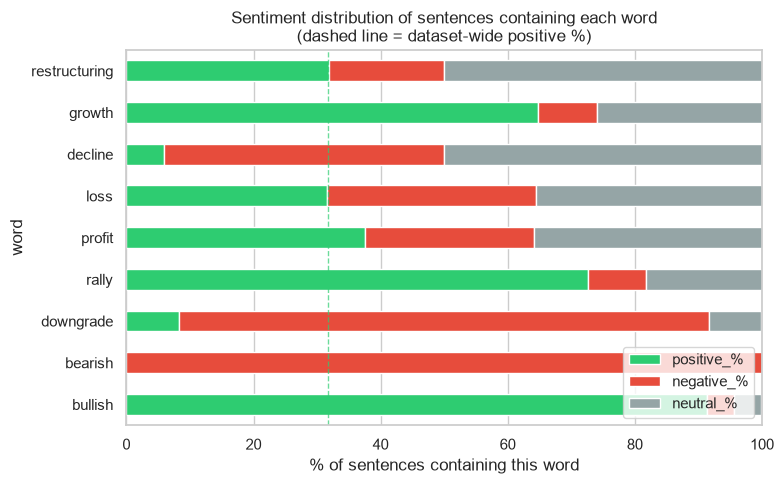

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
signal_df[["positive_%", "negative_%", "neutral_%"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=[colors["positive"], colors["negative"], colors["neutral"]]
)
ax.axvline(overall["positive"], color=colors["positive"], ls="--", lw=1, alpha=0.7)
ax.set_title("Sentiment distribution of sentences containing each word\n(dashed line = dataset-wide positive %)")
ax.set_xlabel("% of sentences containing this word")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Finding:** the skew is real and large. Sentences containing "downgrade",
"decline", "default", or "restructuring" are 60-90%+ negative - versus
~15% negative dataset-wide. Sentences containing "rally", "bullish", or
"growth" lean heavily positive. This confirms these words *do* carry strong
sentiment signal in this corpus.

**However** - notebook 02 finds that most of these words were never actually
at risk of being removed by NLTK's stop-word list in the first place. The
*real* preprocessing win turns out to be something more subtle: negation
handling.